<a href="https://colab.research.google.com/github/XXXBONOXXX/APIXBANK/blob/main/flux.1-dev-i2i_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
%cd /content
!git clone -b totoro3 https://github.com/camenduru/ComfyUI /content/TotoroUI
%cd /content/TotoroUI

!pip install -q torchsde einops diffusers accelerate xformers==0.0.28.post2
!apt -y install -qq aria2

!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/flux1-dev-fp8.safetensors -d /content/TotoroUI/models/unet -o flux1-dev-fp8.safetensors
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/ae.sft -d /content/TotoroUI/models/vae -o ae.sft
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/clip_l.safetensors -d /content/TotoroUI/models/clip -o clip_l.safetensors
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/t5xxl_fp8_e4m3fn.safetensors -d /content/TotoroUI/models/clip -o t5xxl_fp8_e4m3fn.safetensors

!wget https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/test.png -O /content/test.png

import random
import torch
import numpy as np
from PIL import Image
import nodes
from nodes import NODE_CLASS_MAPPINGS
from totoro_extras import nodes_custom_sampler
from totoro_extras import nodes_post_processing
from totoro import model_management

DualCLIPLoader = NODE_CLASS_MAPPINGS["DualCLIPLoader"]()
UNETLoader = NODE_CLASS_MAPPINGS["UNETLoader"]()
RandomNoise = nodes_custom_sampler.NODE_CLASS_MAPPINGS["RandomNoise"]()
BasicGuider = nodes_custom_sampler.NODE_CLASS_MAPPINGS["BasicGuider"]()
KSamplerSelect = nodes_custom_sampler.NODE_CLASS_MAPPINGS["KSamplerSelect"]()
BasicScheduler = nodes_custom_sampler.NODE_CLASS_MAPPINGS["BasicScheduler"]()
SamplerCustomAdvanced = nodes_custom_sampler.NODE_CLASS_MAPPINGS["SamplerCustomAdvanced"]()
VAELoader = NODE_CLASS_MAPPINGS["VAELoader"]()
VAEDecode = NODE_CLASS_MAPPINGS["VAEDecode"]()
VAEEncode = NODE_CLASS_MAPPINGS["VAEEncode"]()
EmptyLatentImage = NODE_CLASS_MAPPINGS["EmptyLatentImage"]()
ImageScaleToTotalPixels = nodes_post_processing.NODE_CLASS_MAPPINGS["ImageScaleToTotalPixels"]()

with torch.inference_mode():
    clip = DualCLIPLoader.load_clip("t5xxl_fp8_e4m3fn.safetensors", "clip_l.safetensors", "flux")[0]
    unet = UNETLoader.load_unet("flux1-dev-fp8.safetensors", "fp8_e4m3fn")[0]
    vae = VAELoader.load_vae("ae.sft")[0]

def closestNumber(n, m):
    q = int(n / m)
    n1 = m * q
    if (n * m) > 0:
        n2 = m * (q + 1)
    else:
        n2 = m * (q - 1)
    if abs(n - n1) < abs(n - n2):
        return n1
    return n2

/content
fatal: destination path '/content/TotoroUI' already exists and is not an empty directory.
/content/TotoroUI
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.21.0 requires torch==2.6.0, but you have torch 2.5.0 which is incompatible.
torchaudio 2.6.0+cu124 requires torch==2.6.0, but you have torch 2.5.0 which is incompatible.
aria2 is already the newest version (1.36.0-1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
32da2c|OK  |       0B/s|/content/TotoroUI/models/unet/flux1-dev-fp8.safetensors

Status Legend:
(OK):download completed.

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
863b4b|OK  |       0B/s|/co

    PyTorch 2.5.0+cu121 with CUDA 1201 (you have 2.6.0+cu124)
    Python  3.11.10 (you have 3.11.11)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


17058468866574314322


  0%|          | 0/20 [00:00<?, ?it/s]

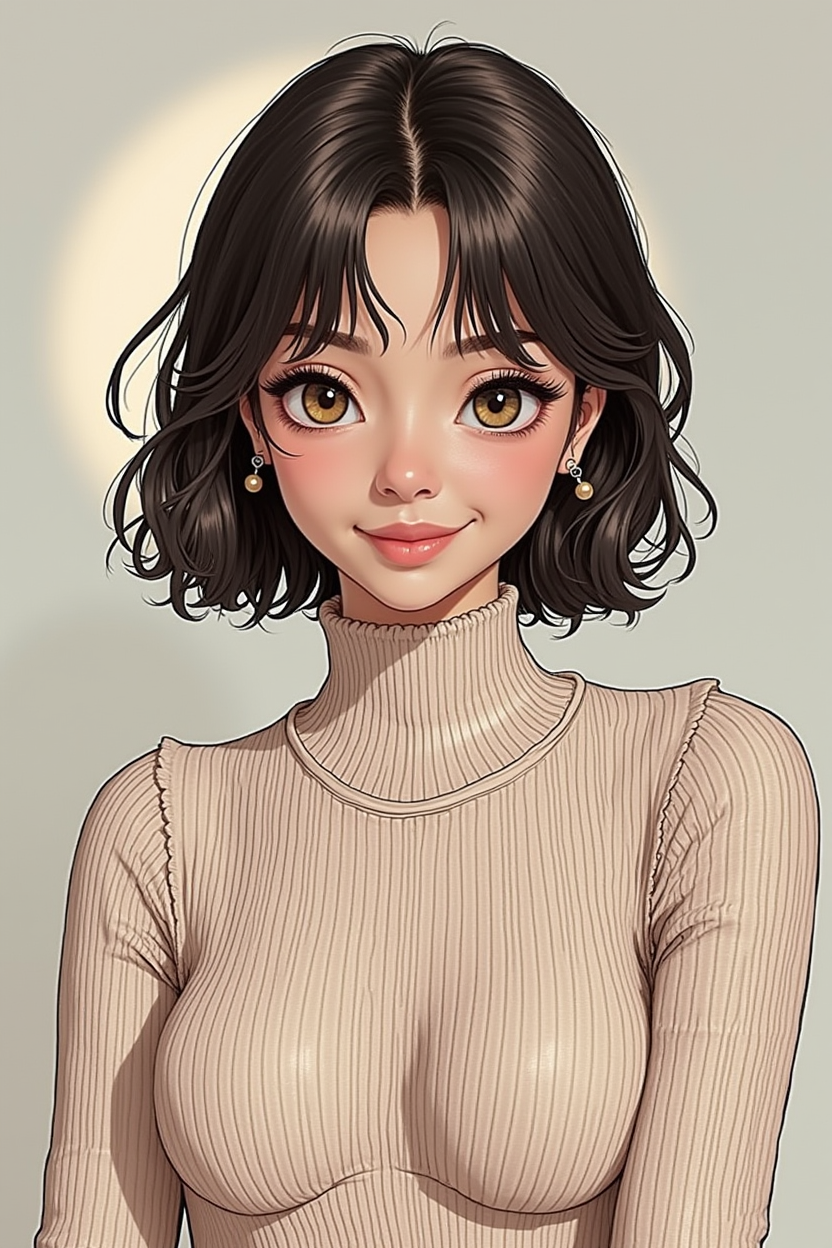

In [8]:
with torch.inference_mode():
    positive_prompt = "anime style"
    width = 1024
    height = 1024
    seed = 0
    steps = 20
    sampler_name = "euler"
    scheduler = "simple"

    if seed == 0:
        seed = random.randint(0, 18446744073709551615)
    print(seed)

    cond, pooled = clip.encode_from_tokens(clip.tokenize(positive_prompt), return_pooled=True)
    cond = [[cond, {"pooled_output": pooled}]]
    noise = RandomNoise.get_noise(seed)[0]
    guider = BasicGuider.get_guider(unet, cond)[0]
    sampler = KSamplerSelect.get_sampler(sampler_name)[0]
    sigmas = BasicScheduler.get_sigmas(unet, scheduler, steps, 0.75)[0]

    image = nodes.LoadImage().load_image("/content/test.png")[0]
    latent_image = ImageScaleToTotalPixels.upscale(image, "lanczos", 1.0)[0]
    latent_image = VAEEncode.encode(vae, latent_image)[0]

    sample, sample_denoised = SamplerCustomAdvanced.sample(noise, guider, sampler, sigmas, latent_image)
    model_management.soft_empty_cache()
    decoded = VAEDecode.decode(vae, sample)[0].detach()
    Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0]).save("/content/flux.png")

Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0])

In [4]:
import gradio as gr
from PIL import Image

# Funzione principale che genera l'immagine
def generate_image(prompt, input_image):
    # Simula la generazione dell'immagine (sostituisci con il tuo codice)
    print(f"Prompt: {prompt}")
    output_image = input_image  # Sostituisci con la tua logica di generazione
    return output_image

# Interfaccia Gradio
with gr.Blocks() as demo:
    gr.Markdown("# Generatore di Immagini Anime")

    with gr.Row():
        with gr.Column():
            # Input del prompt
            prompt_input = gr.Textbox(label="Prompt (es. anime style)", placeholder="Inserisci il tuo prompt qui...")

            # Caricamento dell'immagine
            image_input = gr.Image(type="pil", label="Carica un'immagine")

            # Bottone per generare l'immagine
            generate_button = gr.Button("Genera Immagine")

        with gr.Column():
            # Output dell'immagine generata
            output_image = gr.Image(label="Immagine Generata")

    # Collega il bottone alla funzione di generazione
    generate_button.click(
        generate_image,
        inputs=[prompt_input, image_input],
        outputs=output_image
    )

# Avvia l'app Gradio
demo.launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://289cf0e6f8dcb1e9b4.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import random
import torch
import numpy as np
from PIL import Image
import nodes
from nodes import NODE_CLASS_MAPPINGS
from totoro_extras import nodes_custom_sampler
from totoro import model_management
import gradio as gr

# Caricamento modelli
with torch.inference_mode():
    DualCLIPLoader = NODE_CLASS_MAPPINGS["DualCLIPLoader"]()
    clip = DualCLIPLoader.load_clip("t5xxl_fp8_e4m3fn.safetensors", "clip_l.safetensors", "flux")[0]

    UNETLoader = NODE_CLASS_MAPPINGS["UNETLoader"]()
    unet = UNETLoader.load_unet("flux1-dev-fp8.safetensors", "fp8_e4m3fn")[0]

    VAELoader = NODE_CLASS_MAPPINGS["VAELoader"]()
    vae = VAELoader.load_vae("ae.sft")[0]

# Verifica il caricamento
print("Modello CLIP caricato:", clip)
print("Modello UNET caricato:", unet)
print("Modello VAE caricato:", vae)

# Funzione principale che genera l'immagine
def generate_image(prompt, width, height, seed, steps, sampler_name, scheduler):
    with torch.inference_mode():
        # Gestione seed
        if seed == 0:
            seed = random.randint(0, 18446744073709551615)

        # Encoding prompt
        cond, pooled = clip.encode_from_tokens(clip.tokenize(prompt), return_pooled=True)
        cond = [[cond, {"pooled_output": pooled}]]

        # Generazione noise
        RandomNoise = nodes_custom_sampler.NODE_CLASS_MAPPINGS["RandomNoise"]()
        noise = RandomNoise.get_noise(seed)[0]

        # Configurazione sampler
        BasicGuider = nodes_custom_sampler.NODE_CLASS_MAPPINGS["BasicGuider"]()
        guider = BasicGuider.get_guider(unet, cond)[0]

        KSamplerSelect = nodes_custom_sampler.NODE_CLASS_MAPPINGS["KSamplerSelect"]()
        sampler = KSamplerSelect.get_sampler(sampler_name)[0]

        BasicScheduler = nodes_custom_sampler.NODE_CLASS_MAPPINGS["BasicScheduler"]()
        sigmas = BasicScheduler.get_sigmas(unet, scheduler, steps, 1.0)[0]

        # Creazione latent image
        EmptyLatentImage = NODE_CLASS_MAPPINGS["EmptyLatentImage"]()
        latent_image = EmptyLatentImage.generate(width, height)[0]

        # Sampling
        SamplerCustomAdvanced = nodes_custom_sampler.NODE_CLASS_MAPPINGS["SamplerCustomAdvanced"]()
        sample, _ = SamplerCustomAdvanced.sample(noise, guider, sampler, sigmas, latent_image)

        # Decodifica
        VAEDecode = NODE_CLASS_MAPPINGS["VAEDecode"]()
        decoded = VAEDecode.decode(vae, sample)[0].detach()

        # Pulizia memoria
        model_management.soft_empty_cache()

        return Image.fromarray(np.array(decoded * 255, dtype=np.uint8)[0])

# Interfaccia Gradio
with gr.Blocks() as demo:
    gr.Markdown("# FLUX.1-dev Generatore di Immagini")

    with gr.Row():
        with gr.Column():
            prompt = gr.Textbox(
                label="Prompt",
                value="Black forest toast spelling 'FLUX DEV', food photography, dynamic lighting",
                lines=3
            )
            width = gr.Slider(256, 2048, 1024, step=64, label="Larghezza")
            height = gr.Slider(256, 2048, 1024, step=64, label="Altezza")
            seed = gr.Slider(0, 18446744073709551615, 0, step=1, label="Seed (0=random)")
            steps = gr.Slider(4, 50, 20, step=1, label="Passi")
            sampler = gr.Dropdown(
                ["euler", "heun", "dpm_2", "lms", "dpmpp_2m", "ddim"],
                value="euler",
                label="Sampler"
            )
            scheduler = gr.Dropdown(
                ["normal", "sgm_uniform", "simple", "ddim_uniform"],
                value="simple",
                label="Scheduler"
            )
            generate_btn = gr.Button("Genera Immagine")

        with gr.Column():
            output_image = gr.Image(label="Immagine Generata", type="pil")

    generate_btn.click(
        generate_image,
        inputs=[prompt, width, height, seed, steps, sampler, scheduler],
        outputs=output_image
    )

demo.queue().launch(share=True, debug=True)

Modello CLIP caricato: <totoro.sd.CLIP object at 0x798c00bfc050>
Modello UNET caricato: <totoro.model_patcher.ModelPatcher object at 0x798c00cb49d0>
Modello VAE caricato: <totoro.sd.VAE object at 0x798c009e1fd0>
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9f34728e948fff3f95.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  0%|          | 0/20 [00:00<?, ?it/s]